###Imports + Load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
n1 = pd.read_csv("dataset_all_labeled1.csv")
n2  = pd.read_csv("dataset_all_labeled2.csv")
n3 = pd.read_csv("dataset_all_labeled3.csv")
n4  = pd.read_csv("dataset_all_labeled4.csv")
n5 = pd.read_csv("dataset_all_labeled5.csv")
n6 = pd.read_csv("dataset_all_labeled5.csv")

full = pd.concat([n1,n2,n3,n4,n5,n6], ignore_index=True)
full.to_csv("dataset_all_labeled.csv", index=False)


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_all_labeled.csv")

# Check class balance
print(df["label"].value_counts(normalize=True))

label
0    0.822371
1    0.177629
Name: proportion, dtype: float64


## Method 1 — Keep Original Dataset 

In [3]:
exclude = {
    "node_id","node_mac",
    "window_start_s","window_end_s"
}

X = df.drop(columns=list(exclude) + ["label"])
y = df["label"]

In [4]:
X = X.fillna(X.median(numeric_only=True))

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
##Logistic Regression (baseline)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     42630
           1       0.97      0.65      0.78      9208

    accuracy                           0.93     51838
   macro avg       0.95      0.82      0.87     51838
weighted avg       0.94      0.93      0.93     51838



In [ ]:
## Random Forest (very strong for your case)

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, pred))

Random Forest
              precision    recall  f1-score   support

           0       1.00      0.86      0.92     42630
           1       0.60      0.99      0.75      9208

    accuracy                           0.88     51838
   macro avg       0.80      0.92      0.84     51838
weighted avg       0.93      0.88      0.89     51838



In [ ]:
## Gradient Boosting (optional but powerful)

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)
pred = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     42630
           1       1.00      0.83      0.90      9208

    accuracy                           0.97     51838
   macro avg       0.98      0.91      0.94     51838
weighted avg       0.97      0.97      0.97     51838




Prediction counts:
prediction
0    17075
1     6457
Name: count, dtype: int64

Sample predictions:
   boot_id  prediction
0    36219           0
1    36219           0
2    36219           0
3    36219           0
4    36219           0

Node-level Sybil statistics:
         total_windows  sybil_windows  sybil_ratio
boot_id                                           
36219             5883           4295     0.730070
34483             5883            926     0.157403
45241             5883            743     0.126296
42825             5883            493     0.083801

Likely Sybil nodes:
         total_windows  sybil_windows  sybil_ratio
boot_id                                           
36219             5883           4295      0.73007


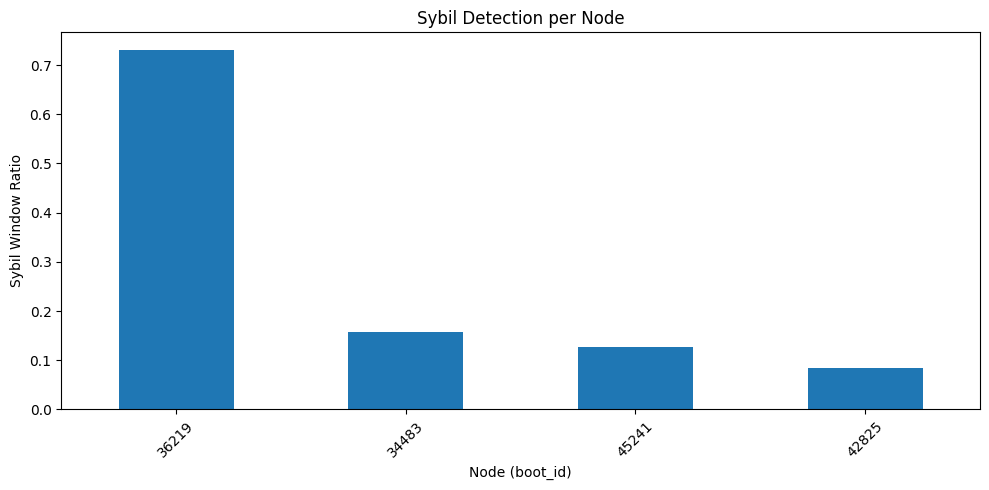


Saved node-level statistics to node_sybil_statistics.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load new dataset
# -----------------------------
new_df = pd.read_csv("real.csv")

# -----------------------------
# 2. Prepare feature matrix
# -----------------------------
exclude = {
    "boot_id",
    "node_id",
    "node_mac",
    "window_start_s",
    "window_end_s"
}

# keep features only
X = new_df.drop(columns=list(exclude) + ["label"], errors="ignore")

# fill missing values
X = X.fillna(X.median(numeric_only=True))

# -----------------------------
# 3. Predict windows
# -----------------------------
pred = gb.predict(X)

new_df["prediction"] = pred

print("\nPrediction counts:")
print(new_df["prediction"].value_counts())

# -----------------------------
# 4. Show predictions with node ID
# -----------------------------
print("\nSample predictions:")
print(new_df[["boot_id","prediction"]].head())

# -----------------------------
# 5. Compute node-level statistics
# -----------------------------
node_stats = new_df.groupby("boot_id")["prediction"].agg(
    total_windows="count",
    sybil_windows="sum"
)

# calculate ratio
node_stats["sybil_ratio"] = node_stats["sybil_windows"] / node_stats["total_windows"]

# sort nodes by ratio
node_stats = node_stats.sort_values("sybil_ratio", ascending=False)

print("\nNode-level Sybil statistics:")
print(node_stats)

# -----------------------------
# 6. Identify likely Sybil nodes
# -----------------------------
threshold = 0.5

sybil_nodes = node_stats[node_stats["sybil_ratio"] > threshold]

print("\nLikely Sybil nodes:")
print(sybil_nodes)

# -----------------------------
# 7. Plot Sybil ratio per node
# -----------------------------
plt.figure(figsize=(10,5))

node_stats["sybil_ratio"].plot(kind="bar")

plt.ylabel("Sybil Window Ratio")
plt.xlabel("Node (boot_id)")
plt.title("Sybil Detection per Node")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# -----------------------------
# 8. Save results
# -----------------------------
node_stats.to_csv("node_sybil_statistics.csv")

print("\nSaved node-level statistics to node_sybil_statistics.csv")

In [32]:
# Load new dataset
new_df = pd.read_csv("real.csv")

exclude = {
    "boot_id","node_mac",
    "window_start_s","window_end_s"
}

X = new_df.drop(columns=list(exclude)+ ["label"], errors="ignore")
X = X.fillna(X.median(numeric_only=True))

# Predict
pred = gb.predict(X)

new_df["boot_id","prediction"] = pred

print(new_df["boot_id","prediction"].value_counts())

(boot_id, prediction)
0    17208
1     6324
Name: count, dtype: int64


In [ ]:
## Neural Network (MLP)

In [11]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)
pred = mlp.predict(X_test)

print("Neural Network (MLP)")
print(classification_report(y_test, pred))

Neural Network (MLP)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     42630
           1       1.00      0.83      0.91      9208

    accuracy                           0.97     51838
   macro avg       0.98      0.91      0.94     51838
weighted avg       0.97      0.97      0.97     51838




Prediction counts:
prediction
0    14740
1     8792
Name: count, dtype: int64

Sample predictions:
   boot_id  prediction
0    36219           0
1    36219           0
2    36219           0
3    36219           0
4    36219           0

Node-level Sybil statistics:
         total_windows  sybil_windows  sybil_ratio
boot_id                                           
36219             5883           4359     0.740948
42825             5883           4353     0.739929
45241             5883             76     0.012919
34483             5883              4     0.000680

Likely Sybil nodes:
         total_windows  sybil_windows  sybil_ratio
boot_id                                           
36219             5883           4359     0.740948
42825             5883           4353     0.739929


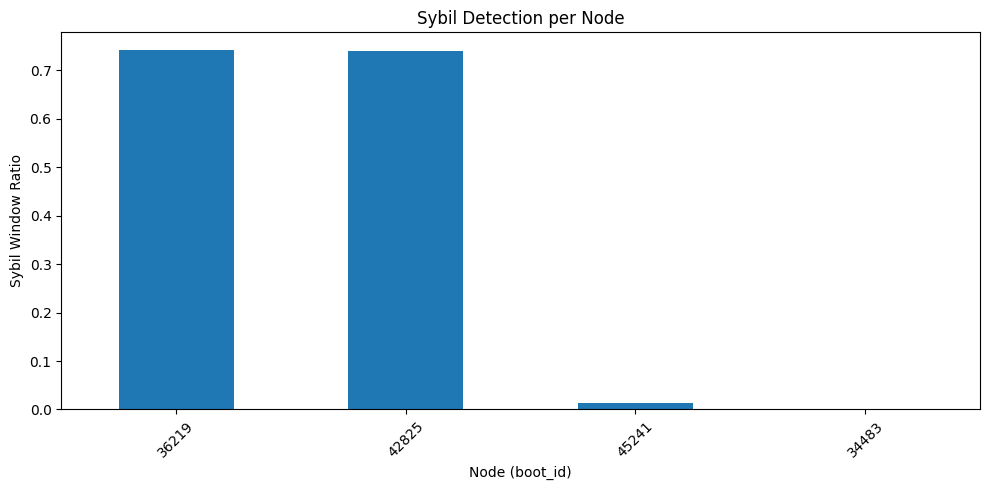


Saved node-level statistics to node_sybil_statistics.csv


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load new dataset
# -----------------------------
new_df = pd.read_csv("real.csv")

# -----------------------------
# 2. Prepare feature matrix
# -----------------------------
exclude = {
    "boot_id",
    "node_id",
    "node_mac",
    "window_start_s",
    "window_end_s"
}

# keep features only
X = new_df.drop(columns=list(exclude) + ["label"], errors="ignore")

# fill missing values
X = X.fillna(X.median(numeric_only=True))

# -----------------------------
# 3. Predict windows
# -----------------------------
pred =mlp.predict(X)

new_df["prediction"] = pred
new_df.to_csv("model_predictions.csv", index=False)
print("\nPrediction counts:")
print(new_df["prediction"].value_counts())

# -----------------------------
# 4. Show predictions with node ID
# -----------------------------
print("\nSample predictions:")
print(new_df[["boot_id","prediction"]].head())

# -----------------------------
# 5. Compute node-level statistics
# -----------------------------
node_stats = new_df.groupby("boot_id")["prediction"].agg(
    total_windows="count",
    sybil_windows="sum"
)

# calculate ratio
node_stats["sybil_ratio"] = node_stats["sybil_windows"] / node_stats["total_windows"]

# sort nodes by ratio
node_stats = node_stats.sort_values("sybil_ratio", ascending=False)

print("\nNode-level Sybil statistics:")
print(node_stats)

# -----------------------------
# 6. Identify likely Sybil nodes
# -----------------------------
threshold = 0.5

sybil_nodes = node_stats[node_stats["sybil_ratio"] > threshold]

print("\nLikely Sybil nodes:")
print(sybil_nodes)

# -----------------------------
# 7. Plot Sybil ratio per node
# -----------------------------
plt.figure(figsize=(10,5))

node_stats["sybil_ratio"].plot(kind="bar")

plt.ylabel("Sybil Window Ratio")
plt.xlabel("Node (boot_id)")
plt.title("Sybil Detection per Node")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# -----------------------------
# 8. Save results
# -----------------------------
node_stats.to_csv("node_sybil_statistics.csv")

print("\nSaved node-level statistics to node_sybil_statistics.csv")

In [23]:
# Load new dataset
new_df = pd.read_csv("real.csv")

exclude = {
    "boot_id","node_mac",
    "window_start_s","window_end_s"
}

X = new_df.drop(columns=list(exclude)+ ["label"], errors="ignore")
X = X.fillna(X.median(numeric_only=True))

# Predict
pred = mlp.predict(X)

new_df["prediction"] = pred

print(new_df["prediction"].value_counts())

prediction
0    14800
1     8732
Name: count, dtype: int64


In [8]:
## Compare Models

In [11]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": logreg,
    "RF": rf,
    "GB": gb,
    "MLP": mlp
}

results = []

for name, model in models.items():
    p = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1] if hasattr(model,"predict_proba") else None

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test,p),
        "f1": f1_score(y_test,p),
        "roc_auc": roc_auc_score(y_test, prob) if prob is not None else None
    })

pd.DataFrame(results)

,model,accuracy,f1,roc_auc
0,LogReg,0.921587,0.705903,0.888665
1,RF,0.880445,0.734351,0.983076
2,GB,0.963338,0.878621,0.982449
3,MLP,0.964323,0.882011,0.982092


In [12]:
import pandas as pd

imp = pd.Series(rf.feature_importances_, index=X.columns)
imp.sort_values(ascending=False).head(15)

udp_pkt_count        0.186789
iat_mean             0.176845
pps                  0.148223
rssi_mean            0.142297
rssi_max             0.120533
iat_std              0.058981
rssi_min             0.057123
rssi_frame_count     0.053623
seq_gap_mean         0.017750
rssi_std             0.016930
seq_gap_max          0.016873
rssi_missing         0.003971
out_of_order_rate    0.000062
seq_reset_rate       0.000000
dup_seq_rate         0.000000
dtype: float64

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    verbose=1
)

model.evaluate(X_test_s, y_test)

c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9463 - loss: 0.1717 - val_accuracy: 0.9540 - val_loss: 0.1497
Epoch 2/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9548 - loss: 0.1262 - val_accuracy: 0.9575 - val_loss: 0.1191
Epoch 3/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9581 - loss: 0.1127 - val_accuracy: 0.9596 - val_loss: 0.1100
Epoch 4/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9599 - loss: 0.1082 - val_accuracy: 0.9606 - val_loss: 0.1100
Epoch 5/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9604 - loss: 0.1065 - val_accuracy: 0.9607 - val_loss: 0.1059
Epoch 6/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9608 - loss: 0.1045 - val_accuracy: 0.9612 - val_loss: 0.1107
Epoch 7/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9611 - loss: 0.1034 - val_accuracy: 0.9617 - val_loss: 0.1047
Epoch 8/40
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9614 - loss: 0.1026 - 

[0.09973494708538055, 0.9643937945365906]

In [ ]:
##Evaluation

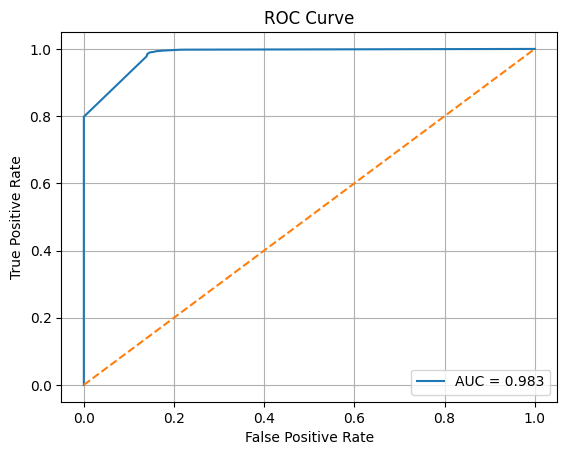

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Example: Random Forest model
model = rf   # change to logreg, gb, mlp if needed

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

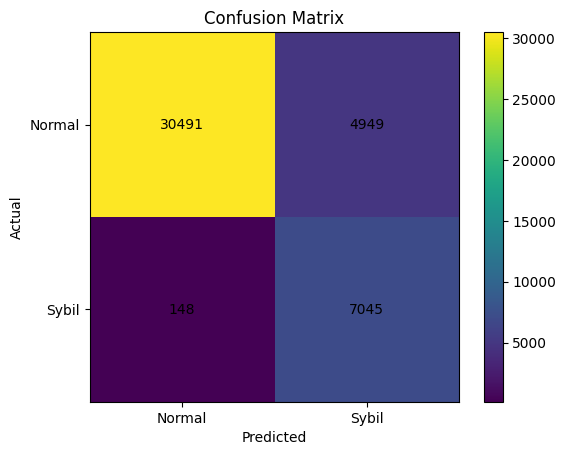

In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, model.predict(X_test))

plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xticks([0,1],["Normal","Sybil"])
plt.yticks([0,1],["Normal","Sybil"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

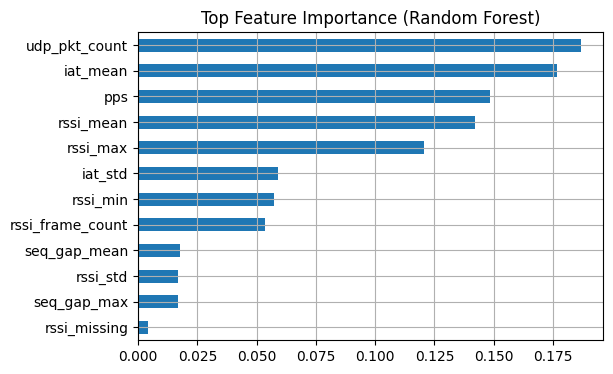

In [16]:
import pandas as pd

imp = pd.Series(rf.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False).head(12)

plt.figure(figsize=(6,4))
imp.plot(kind="barh")
plt.title("Top Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

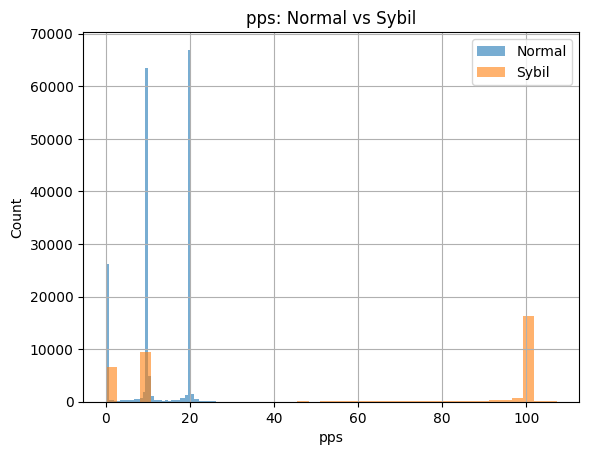

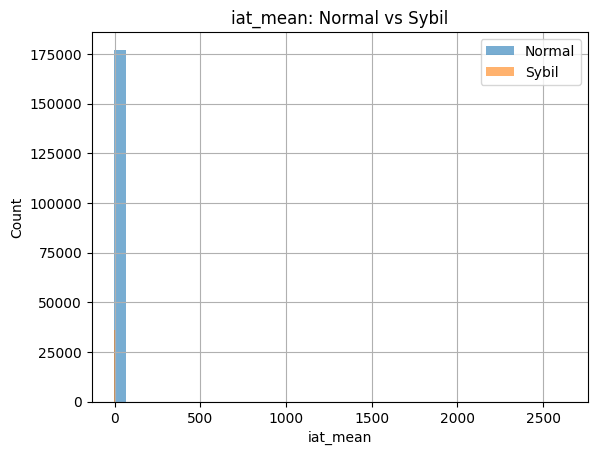

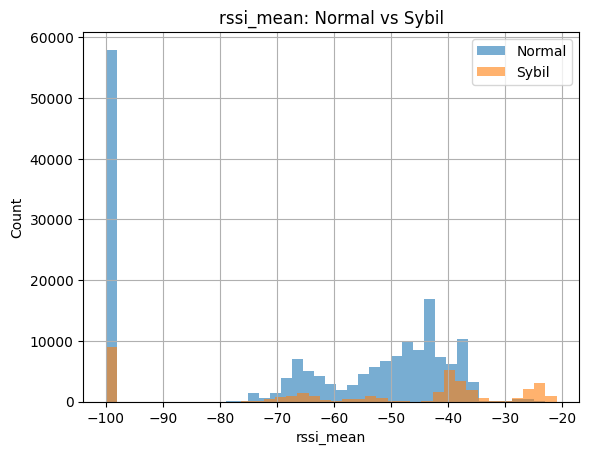

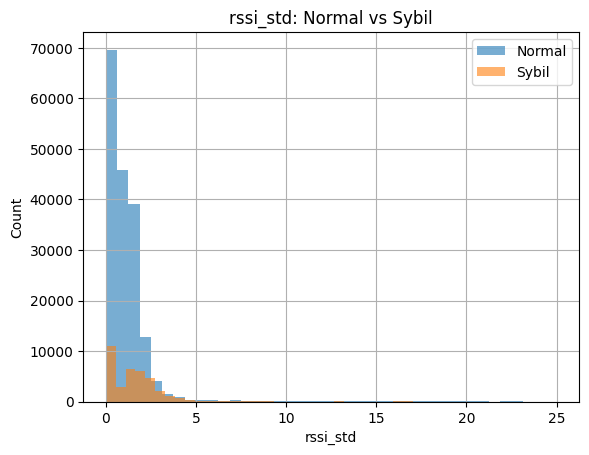

In [17]:
import matplotlib.pyplot as plt

features = ["pps","iat_mean","rssi_mean","rssi_std"]

for f in features:
    plt.figure()

    plt.hist(df[df["label"]==0][f], bins=40, alpha=0.6, label="Normal")
    plt.hist(df[df["label"]==1][f], bins=40, alpha=0.6, label="Sybil")

    plt.title(f"{f}: Normal vs Sybil")
    plt.xlabel(f)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()

c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_l

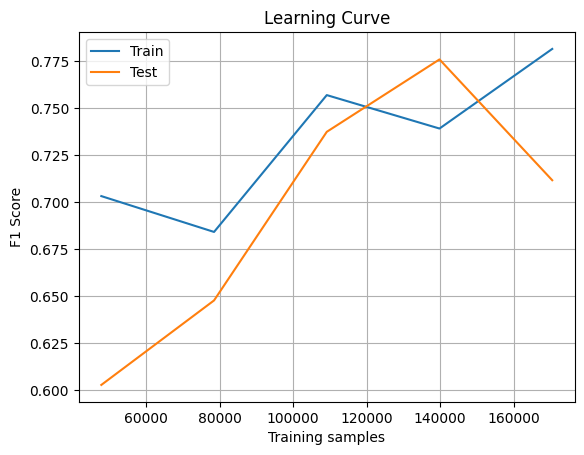

In [18]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring="f1",
    train_sizes=np.linspace(0.1,1.0,6)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")

plt.xlabel("Training samples")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42
    ),
    "GradBoost": GradientBoostingClassifier(random_state=42),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64,32),
            activation="relu",
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

for name, m in models.items():
    m.fit(X_train, y_train)
    print("trained:", name)

trained: LogReg
trained: RandomForest
trained: GradBoost
trained: MLP



MODEL: LogReg
Average inference time per sample: 0.0003 ms
              precision    recall  f1-score   support

           0     0.9173    0.9954    0.9548     35440
           1     0.9612    0.5578    0.7059      7193

    accuracy                         0.9216     42633
   macro avg     0.9392    0.7766    0.8303     42633
weighted avg     0.9247    0.9216    0.9128     42633



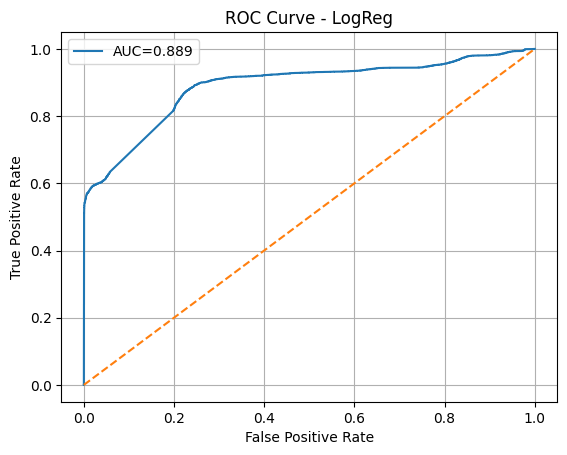

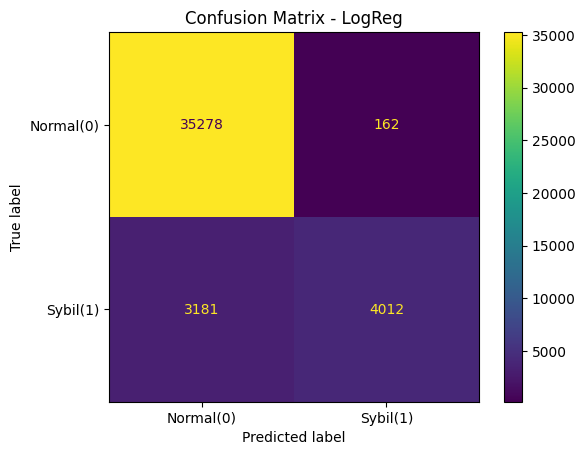


MODEL: RandomForest
Average inference time per sample: 0.0225 ms
              precision    recall  f1-score   support

           0     0.9952    0.8604    0.9229     35440
           1     0.5874    0.9794    0.7344      7193

    accuracy                         0.8804     42633
   macro avg     0.7913    0.9199    0.8286     42633
weighted avg     0.9264    0.8804    0.8911     42633



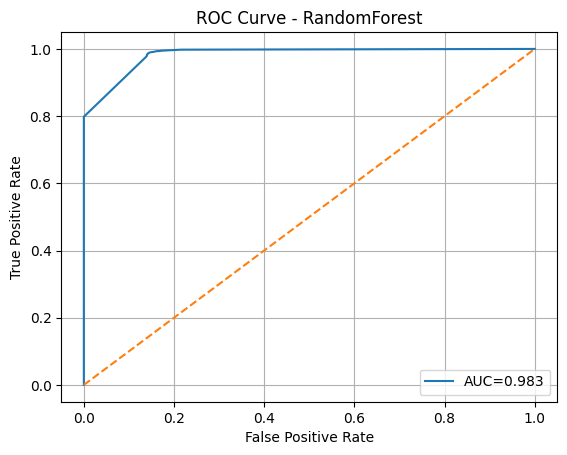

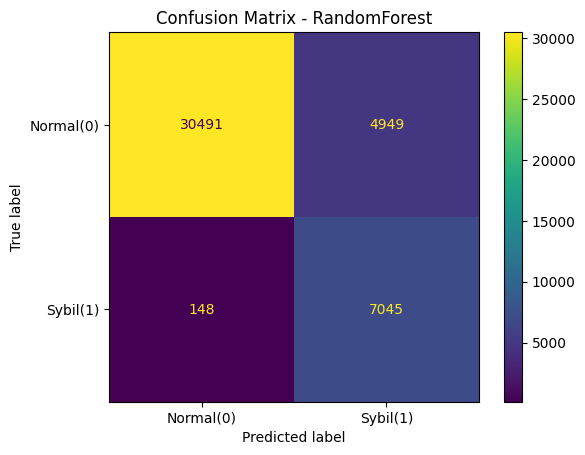


MODEL: GradBoost
Average inference time per sample: 0.0020 ms
              precision    recall  f1-score   support

           0     0.9584    0.9992    0.9784     35440
           1     0.9952    0.7865    0.8786      7193

    accuracy                         0.9633     42633
   macro avg     0.9768    0.8928    0.9285     42633
weighted avg     0.9646    0.9633    0.9616     42633



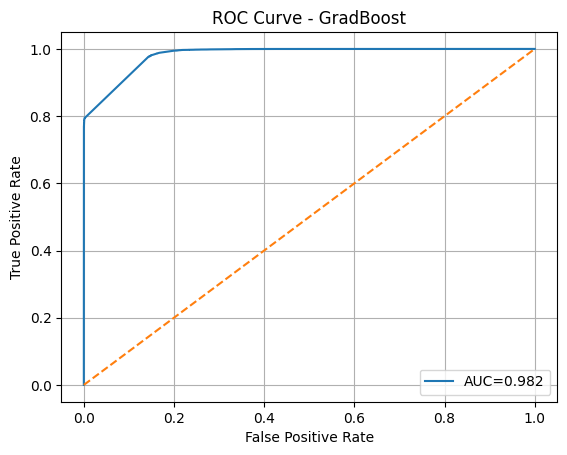

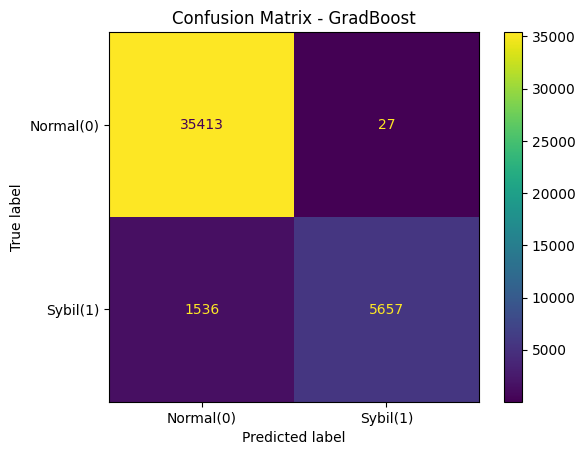


MODEL: MLP
Average inference time per sample: 0.0007 ms
              precision    recall  f1-score   support

           0     0.9592    0.9996    0.9790     35440
           1     0.9977    0.7904    0.8820      7193

    accuracy                         0.9643     42633
   macro avg     0.9784    0.8950    0.9305     42633
weighted avg     0.9657    0.9643    0.9626     42633



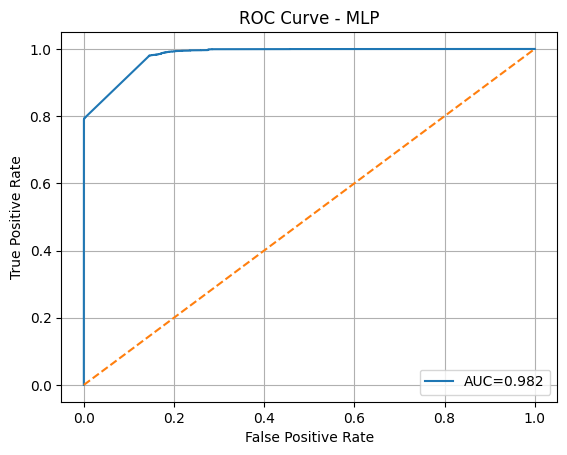

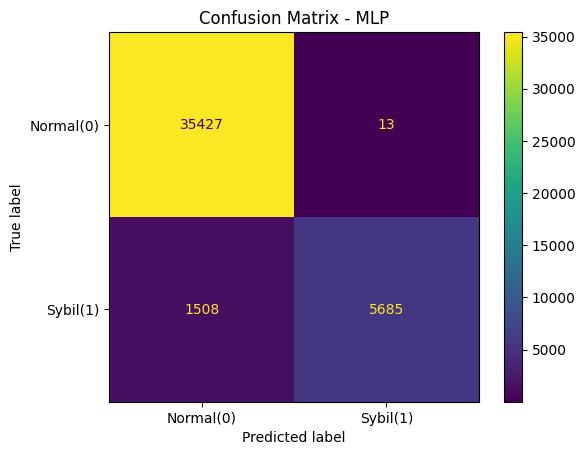

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report

def get_proba(model, X):
    # Works for pipelines and normal models
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:,1]

    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s = (s - s.min()) / (s.max() - s.min() + 1e-9)
        return s

    raise ValueError("Model has no predict_proba or decision_function")


for name, model in models.items():

    print("\n==============================")
    print("MODEL:", name)

    # -------------------------
    # Measure inference time
    # -------------------------
    start = time.time()
    y_pred = model.predict(X_test)
    end = time.time()

    inference_time = (end - start) / len(X_test)

    print(f"Average inference time per sample: {inference_time*1000:.4f} ms")

    # Probabilities
    y_prob = get_proba(model, X_test)

    # -------------------------
    # Classification report
    # -------------------------
    print(classification_report(y_test, y_pred, digits=4))

    # -------------------------
    # ROC Curve
    # -------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # Confusion Matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["Normal(0)","Sybil(1)"]
    )

    disp.plot(values_format="d")

    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()


MODEL: LogReg
              precision    recall  f1-score   support

           0     0.9173    0.9954    0.9548     35440
           1     0.9612    0.5578    0.7059      7193

    accuracy                         0.9216     42633
   macro avg     0.9392    0.7766    0.8303     42633
weighted avg     0.9247    0.9216    0.9128     42633



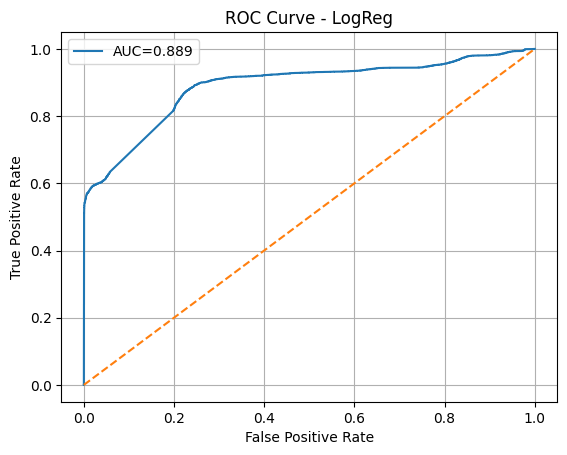

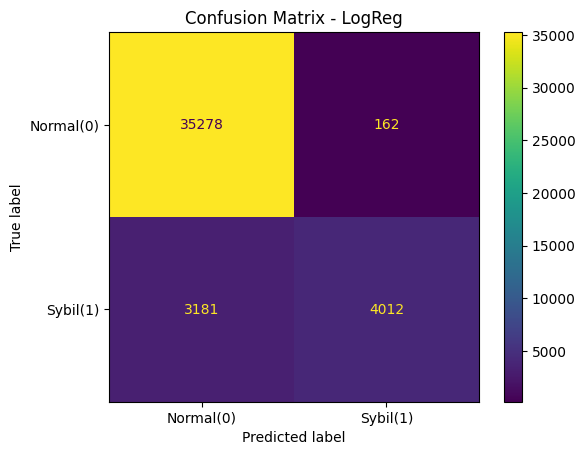


MODEL: RandomForest
              precision    recall  f1-score   support

           0     0.9952    0.8604    0.9229     35440
           1     0.5874    0.9794    0.7344      7193

    accuracy                         0.8804     42633
   macro avg     0.7913    0.9199    0.8286     42633
weighted avg     0.9264    0.8804    0.8911     42633



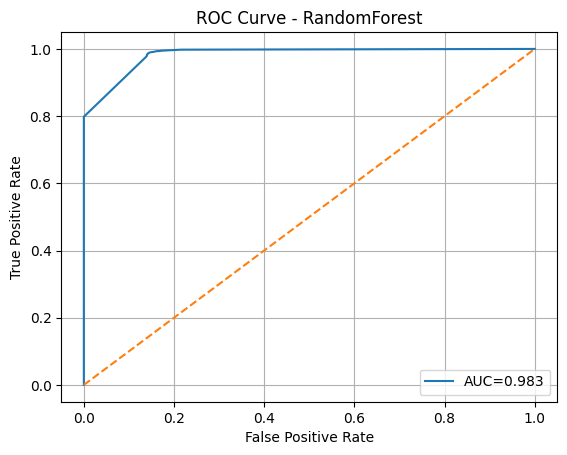

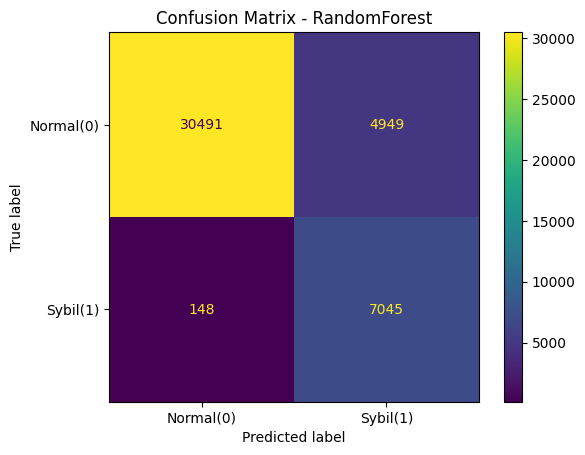


MODEL: GradBoost
              precision    recall  f1-score   support

           0     0.9584    0.9992    0.9784     35440
           1     0.9952    0.7865    0.8786      7193

    accuracy                         0.9633     42633
   macro avg     0.9768    0.8928    0.9285     42633
weighted avg     0.9646    0.9633    0.9616     42633



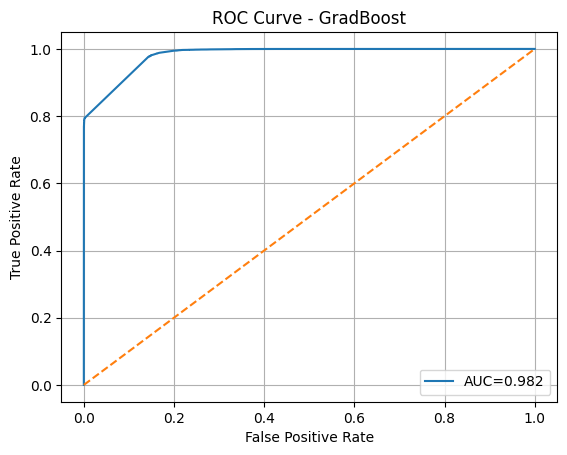

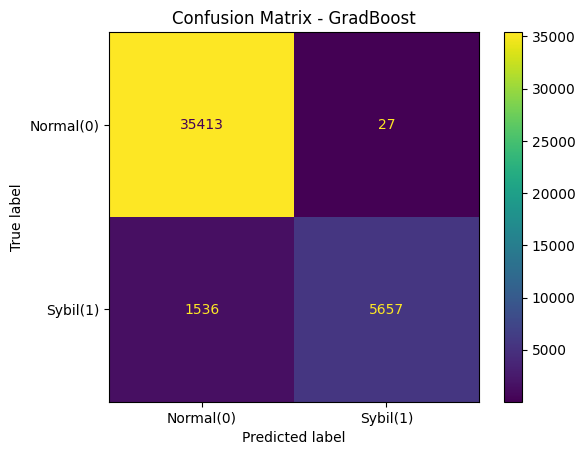


MODEL: MLP
              precision    recall  f1-score   support

           0     0.9592    0.9996    0.9790     35440
           1     0.9977    0.7904    0.8820      7193

    accuracy                         0.9643     42633
   macro avg     0.9784    0.8950    0.9305     42633
weighted avg     0.9657    0.9643    0.9626     42633



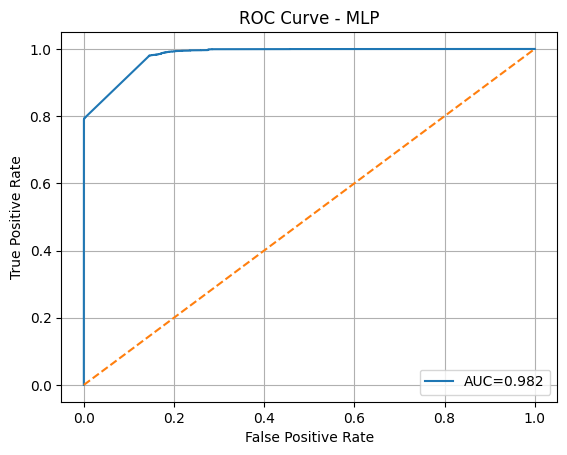

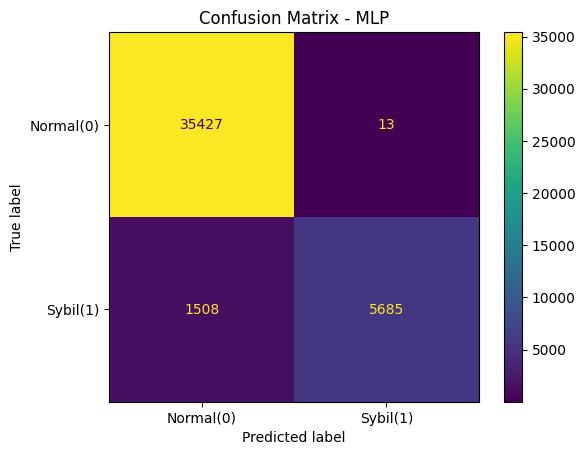

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
import time

def get_proba(model, X):
    # Works for pipelines and normal models
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:,1]
    # If a model doesn't support predict_proba, fallback to decision_function
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        # scale to 0-1 for ROC (not a true probability but OK for ROC curve)
        s = (s - s.min()) / (s.max() - s.min() + 1e-9)
        return s
    raise ValueError("Model has no predict_proba or decision_function")

for name, model in models.items():

     # -------------------------
    # Measure inference time
    # -------------------------
    start = time.time()
    y_pred = model.predict(X_test)
    end = time.time()

    inference_time = (end - start) / len(X_test)

    print(f"Average inference time per sample: {inference_time*1000:.4f} ms")
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = get_proba(model, X_test)

    print("\n==============================")
    print("MODEL:", name)
    print(classification_report(y_test, y_pred, digits=4))

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal(0)","Sybil(1)"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()


--- Feature importance for LogReg ---


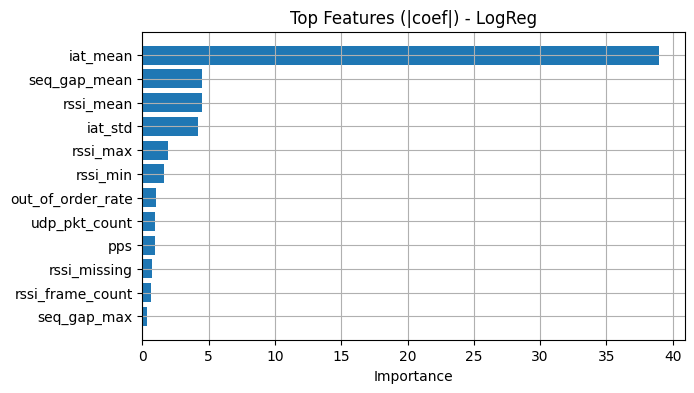


--- Feature importance for RandomForest ---


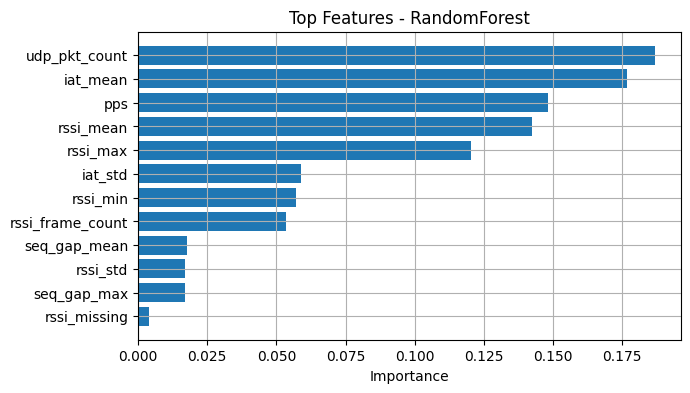


--- Feature importance for GradBoost ---


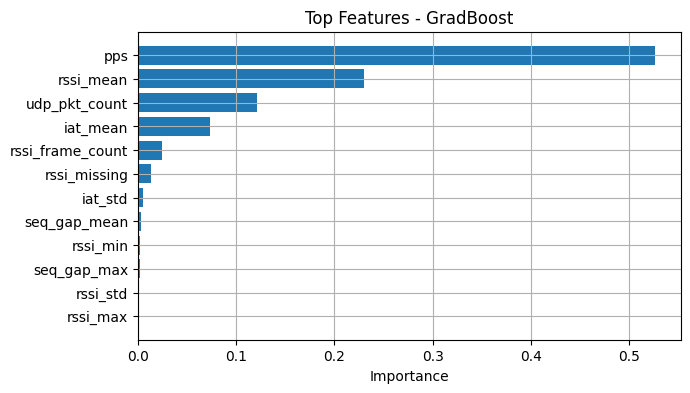


--- Feature importance for MLP ---


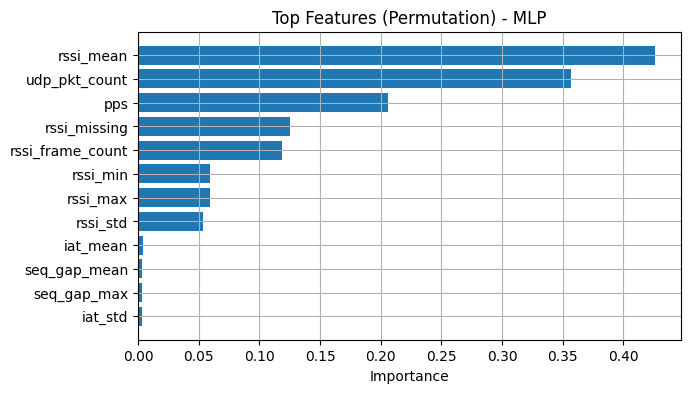

In [21]:
import pandas as pd
from sklearn.inspection import permutation_importance

feature_names = X_train.columns

def plot_top(series, title, topk=12):
    s = series.sort_values(ascending=False).head(topk)
    plt.figure(figsize=(7,4))
    plt.barh(s.index[::-1], s.values[::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.grid(True)
    plt.show()

for name, model in models.items():
    print("\n--- Feature importance for", name, "---")

    if name in ["RandomForest", "GradBoost"]:
        imp = pd.Series(model.feature_importances_, index=feature_names)
        plot_top(imp, f"Top Features - {name}")

    elif name == "LogReg":
        # Get coefficients from pipeline
        clf = model.named_steps["clf"]
        coef = pd.Series(np.abs(clf.coef_[0]), index=feature_names)
        plot_top(coef, "Top Features (|coef|) - LogReg")

    elif name == "MLP":
        # Permutation importance (slow but reliable)
        r = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, scoring="f1")
        imp = pd.Series(r.importances_mean, index=feature_names)
        plot_top(imp, "Top Features (Permutation) - MLP")

## mild weighting

In [ ]:
#Compute Automatic Class Weights

In [23]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))

print(class_weight)

{np.int64(0): np.float64(0.601487767713536), np.int64(1): np.float64(2.963351058283808)}


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight=class_weight
        ))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight=class_weight,
        random_state=42
    ),

    "GradBoost": GradientBoostingClassifier(
        random_state=42
    ),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64,32),
            activation="relu",
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

In [26]:
for name, m in models.items():

    if name == "GradBoost":
        m.fit(X_train, y_train, sample_weight=sample_weights)

    elif name == "MLP":
        m.fit(X_train, y_train, clf__sample_weight=sample_weights)

    else:
        m.fit(X_train, y_train)

    print("trained:", name)

trained: LogReg
trained: RandomForest
trained: GradBoost
trained: MLP



MODEL: LogReg
              precision    recall  f1-score   support

           0     0.9255    0.9519    0.9385     35440
           1     0.7244    0.6224    0.6696      7193

    accuracy                         0.8963     42633
   macro avg     0.8250    0.7872    0.8040     42633
weighted avg     0.8916    0.8963    0.8932     42633



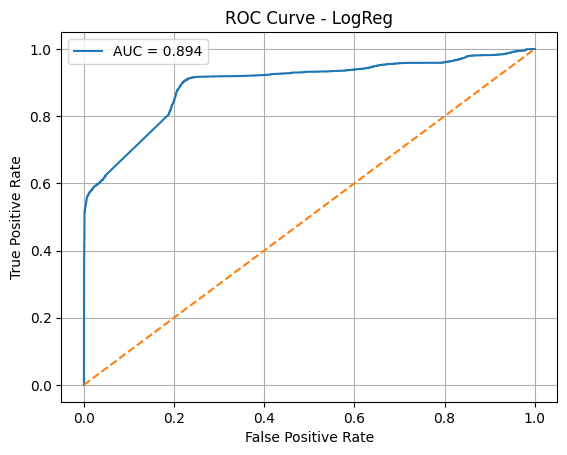

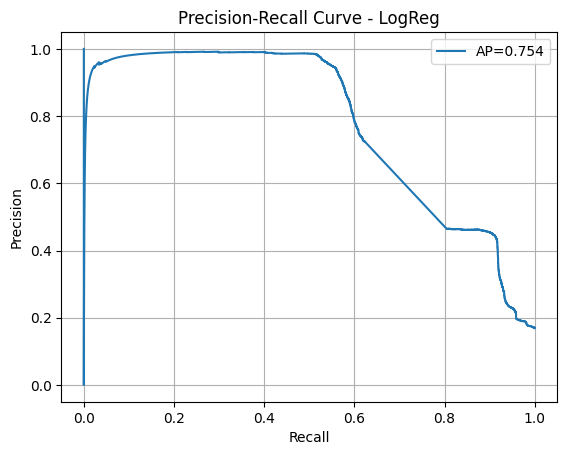

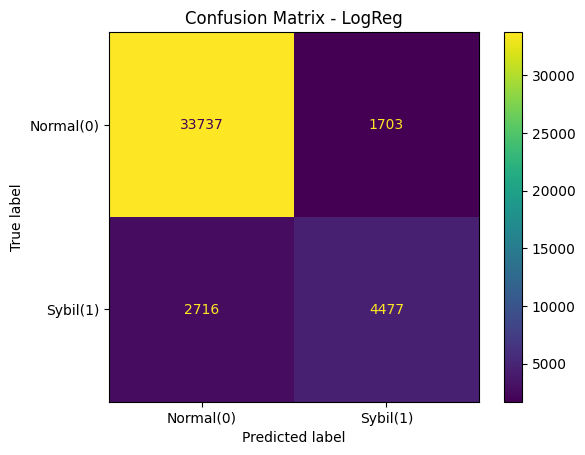

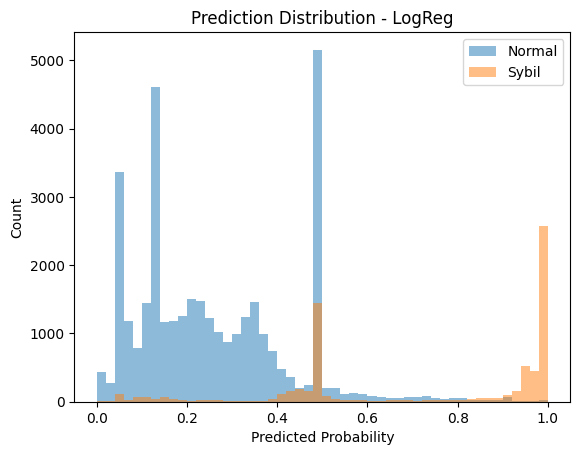


MODEL: RandomForest
              precision    recall  f1-score   support

           0     0.9952    0.8604    0.9229     35440
           1     0.5874    0.9794    0.7344      7193

    accuracy                         0.8804     42633
   macro avg     0.7913    0.9199    0.8286     42633
weighted avg     0.9264    0.8804    0.8911     42633



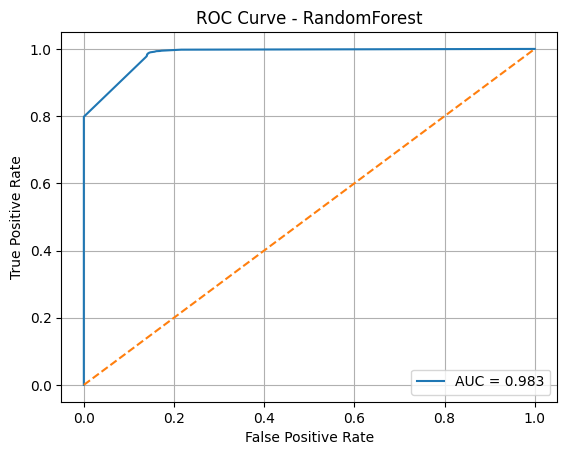

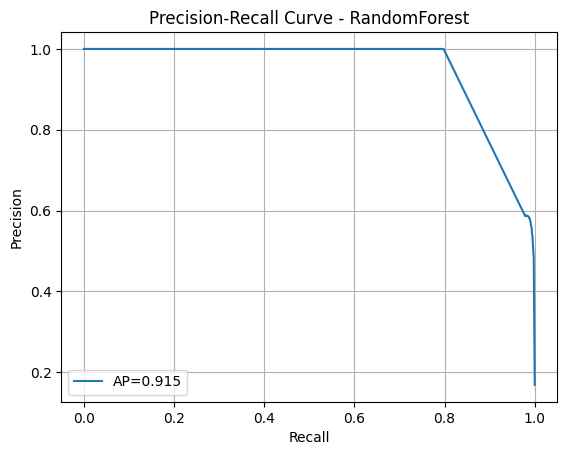

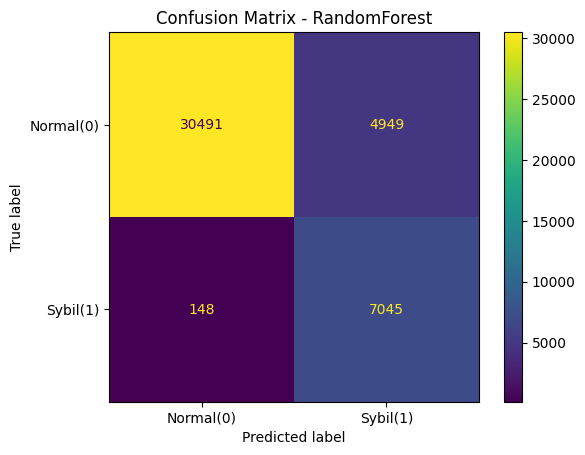

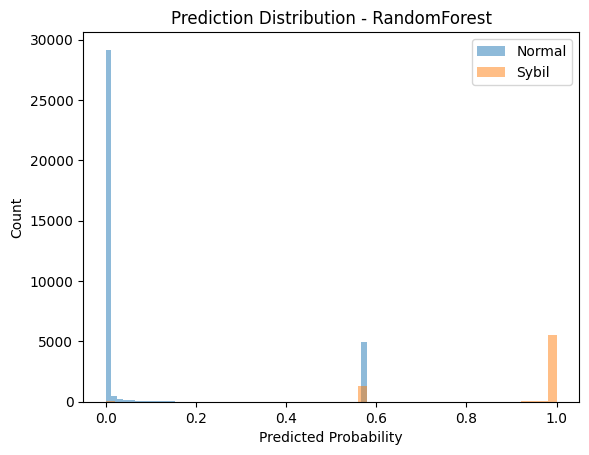


MODEL: GradBoost
              precision    recall  f1-score   support

           0     0.9947    0.8581    0.9214     35440
           1     0.5830    0.9776    0.7304      7193

    accuracy                         0.8782     42633
   macro avg     0.7889    0.9178    0.8259     42633
weighted avg     0.9253    0.8782    0.8891     42633



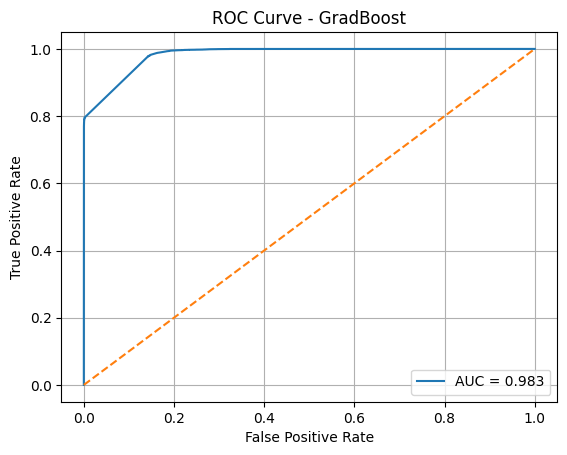

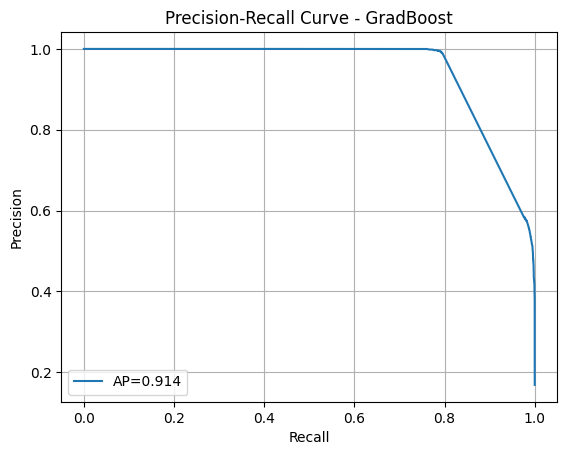

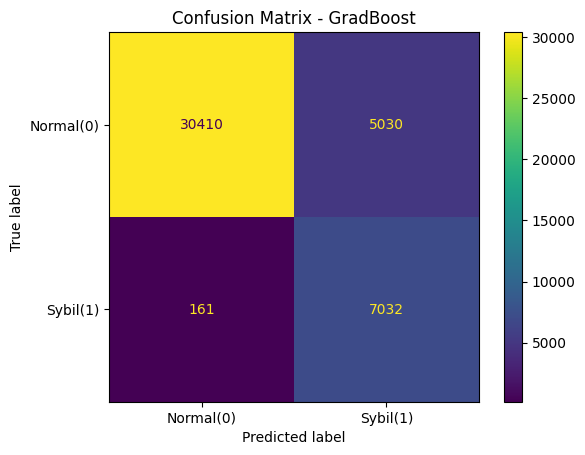

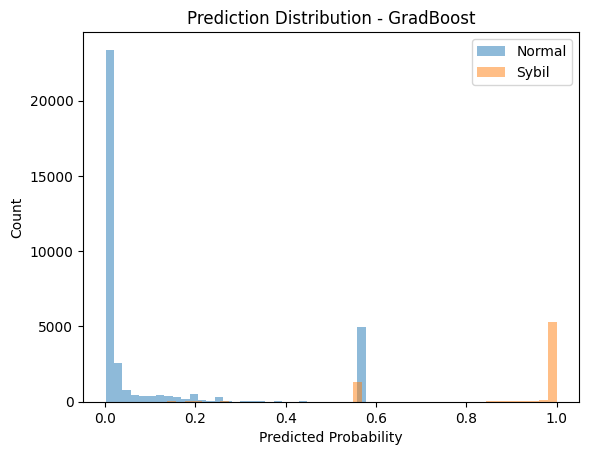


MODEL: MLP
              precision    recall  f1-score   support

           0     0.9953    0.8536    0.9190     35440
           1     0.5760    0.9801    0.7256      7193

    accuracy                         0.8749     42633
   macro avg     0.7856    0.9168    0.8223     42633
weighted avg     0.9245    0.8749    0.8864     42633



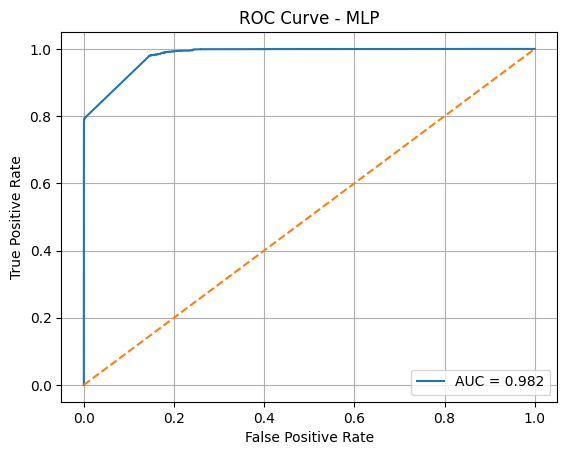

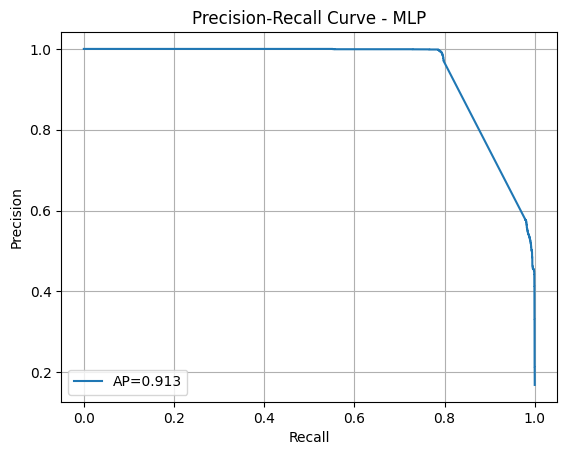

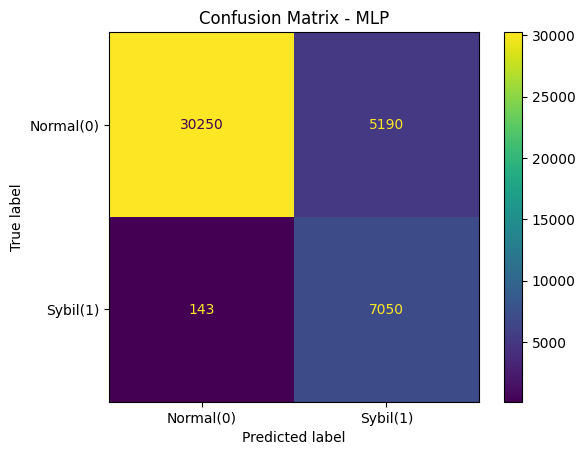

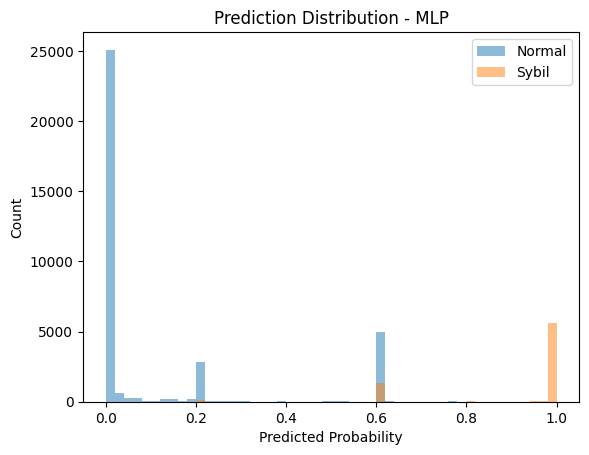

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

def get_proba(model, X):

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:,1]

    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s = (s - s.min()) / (s.max() - s.min() + 1e-9)
        return s

    raise ValueError("Model has no probability output")

for name, model in models.items():

    print("\n==============================")
    print("MODEL:", name)

    y_pred = model.predict(X_test)
    y_prob = get_proba(model, X_test)

    print(classification_report(y_test, y_pred, digits=4))

    # -----------------------------
    # ROC Curve
    # -----------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # Precision Recall Curve
    # -----------------------------
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    plt.figure()
    plt.plot(recall, precision, label=f"AP={pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["Normal(0)", "Sybil(1)"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

    # -----------------------------
    # Probability Histogram
    # -----------------------------
    plt.figure()
    plt.hist(y_prob[y_test==0], bins=50, alpha=0.5, label="Normal")
    plt.hist(y_prob[y_test==1], bins=50, alpha=0.5, label="Sybil")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(f"Prediction Distribution - {name}")
    plt.legend()
    plt.show()

In [ ]:
import pandas as pd

# load dataset
df_real = pd.read_csv("real_world_dataset.csv")

# select same features used in training
X_real = df_real[feature_columns]

# handle missing values same as training
X_real = X_real.fillna(X_real.median())

# predict
y_pred = best_model.predict(X_real)

# prediction probability
y_prob = get_proba(best_model, X_real)

df_real["predicted_label"] = y_pred
df_real["sybil_probability"] = y_prob

df_real.head()